In [1]:
import numpy as np
import os
import json
from zipfile import ZipFile
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import layers, models

2025-03-05 18:31:13.493665: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-05 18:31:13.590757: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-05 18:31:13.619061: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-05 18:31:13.630002: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-05 18:31:13.715701: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import os
import numpy as np
from glob import glob
from keras.preprocessing import image
from sklearn.model_selection import train_test_split

input_dir = "/home/gourib/LIDC-IDRI-slices"
img_shape = (128,128)  # Adjust according to your requirement
Thres = 100  # Threshold for segmentation mask

images = []
masks = []
y = []

# Step 1: Get all patient IDs
patients = sorted(os.listdir(input_dir))

# Step 2: Split patients into train and test sets
train_patients, test_patients = train_test_split(patients, train_size=0.8, random_state=12)

def load_patient_data(patient_list):
    """Load images and masks for the given list of patients"""
    images, masks, labels = [], [], []
    
    for patient in patient_list:
        patient_path = os.path.join(input_dir, patient)
        
        for nodule in os.listdir(patient_path):
            mask0, mask1, mask2, mask3 = [], [], [], []

            # Load images
            for filename in glob(f"{patient_path}/{nodule}/images/*.png"):
                img = image.load_img(filename, target_size=img_shape)
                images.append(np.asarray(img))

            # Load masks
            for filename in glob(f"{patient_path}/{nodule}/mask-0/*.png"):
                img = image.load_img(filename, target_size=img_shape)
                mask1.append(np.asarray(img))

            # Determine final mask selection
            for i in range(len(mask1)):
                white_sum = mask1[i].sum()
                label = 1 if white_sum > Thres else 0
                
                labels.append(label)
                masks.append(mask1[i])
    
    return images, masks, labels

# Step 3: Load training and testing data based on patient-wise split
x_train, mask_train, y_train = load_patient_data(train_patients)
x_test, mask_test, y_test = load_patient_data(test_patients)

# Convert to NumPy arrays
x_train, x_test = np.array(x_train)/255, np.array(x_test)/255
mask_train, mask_test = np.array(mask_train)/255, np.array(mask_test)/255
y_train, y_test = np.array(y_train), np.array(y_test)

# Print shapes
print(x_train.shape, x_test.shape)
print(mask_train.shape, mask_test.shape)

(12052, 128, 128, 3) (3496, 128, 128, 3)
(12052, 128, 128, 3) (3496, 128, 128, 3)


In [3]:

# train_labels = np.array(y_train)
unique, counts = np.unique(y_train, return_counts=True)

# Display the count of each unique value
for u, c in zip(unique, counts):
    print(f"Value {u}: {c} occurrences")

Value 0: 1127 occurrences
Value 1: 10925 occurrences


In [4]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential,load_model
from keras import layers
from keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization,Embedding,TimeDistributed
from keras.layers import Conv2D, MaxPooling2D, ReLU, LSTM,Bidirectional,Attention,Concatenate,concatenate
from keras import regularizers, optimizers,losses
from keras.layers import DepthwiseConv2D,Add, ReLU, GlobalAveragePooling2D, GlobalMaxPooling2D,MultiHeadAttention
from keras.layers import Activation,ActivityRegularization, AvgPool2D, LeakyReLU, Conv2DTranspose
from keras.metrics import Accuracy,Recall,Precision,AUC,TruePositives,TrueNegatives,FalseNegatives,FalsePositives, SpecificityAtSensitivity,SensitivityAtSpecificity
from keras.utils import plot_model
from keras.preprocessing import image
from keras.utils import to_categorical
import numpy as np
import matplotlib
import sklearn
import matplotlib.pyplot as plt
import time
import os
import sklearn.metrics as m
from glob import glob
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

In [5]:

unique, counts = np.unique(y_test, return_counts=True)

# Display the count of each unique value
for u, c in zip(unique, counts):
    print(f"Value {u}: {c} occurrences")

Value 0: 290 occurrences
Value 1: 3206 occurrences


In [6]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.layers import (Conv2D, Conv2DTranspose, Dropout, 
                                     BatchNormalization, concatenate, Input)
from keras.models import Model

# Model Name
Name = "MobileNetV2_U-Net"

# Image Shape (128x128, since MobileNetV2 supports it)
img_shape = (128, 128, 3)

def mobilenet_unet():
    # Load MobileNetV2 without fully connected layers
    mobilenet = MobileNetV2(include_top=False, weights="imagenet", input_shape=img_shape)

    # Freeze the MobileNetV2 encoder layers
    for layer in mobilenet.layers:
        layer.trainable = False

    # Encoder (MobileNetV2)
    c1 = mobilenet.get_layer("block_1_expand_relu").output   # 64x64
    c2 = mobilenet.get_layer("block_3_expand_relu").output   # 32x32
    c3 = mobilenet.get_layer("block_6_expand_relu").output   # 16x16
    c4 = mobilenet.get_layer("block_13_expand_relu").output  # 8x8
    c5 = mobilenet.get_layer("block_16_project").output      # 4x4 (Bottleneck)

    # Decoder (U-Net)
    u6 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding="same")(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(256, (3, 3), activation="relu", padding="same")(u6)
    c6 = BatchNormalization()(c6)
    c6 = Dropout(0.2)(c6)

    u7 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(128, (3, 3), activation="relu", padding="same")(u7)
    c7 = BatchNormalization()(c7)
    c7 = Dropout(0.2)(c7)

    u8 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(64, (3, 3), activation="relu", padding="same")(u8)
    c8 = BatchNormalization()(c8)
    c8 = Dropout(0.1)(c8)

    u9 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(32, (3, 3), activation="relu", padding="same")(u9)
    c9 = BatchNormalization()(c9)
    c9 = Dropout(0.1)(c9)

    # **Extra upsampling layer to restore 128x128 resolution**
    u10 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding="same")(c9)
    c10 = Conv2D(16, (3, 3), activation="relu", padding="same")(u10)
    c10 = BatchNormalization()(c10)

    # Final output layer (128x128x3)
    outputs = Conv2D(3, (1, 1), activation="sigmoid")(c10)

    # Define U-Net model
    model = Model(inputs=mobilenet.input, outputs=outputs, name=Name)
    
    return model

# Create the model
unet_model = mobilenet_unet()
unet_model.summary()


2025-03-05 18:31:34.487577: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:3b:00.0, compute capability: 7.0


Model: "MobileNetV2_U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 4,791,315 (18.28 MB)

 Trainable params: 2,948,339 (11.25 MB)

 Non-trainable params: 1,842,976 (7.03 MB)

In [1]:
def dice_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# IoU (Jaccard Index)
def iou_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
        return (intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# Model Compilation
model= mobilenet_unet()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
        loss=dice_loss, 
        metrics=[dice_coef, iou_coef, tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])
#model.summary()

NameError: name 'mobilenet_unet' is not defined

In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
checkpointer = ModelCheckpoint(Name + '_checkpoint.weights.h5', verbose=1, save_best_only=True, save_weights_only=True)


ModuleNotFoundError: No module named 'tensorflow.keras'

In [9]:
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
#Name = 'mobbb_unet1'
#earlystopper = EarlyStopping(patience=100, verbose=1)
#checkpointer = ModelCheckpoint(Name + '_checkpoint.keras', verbose=1, save_best_only=True)
results = model.fit(x_train,mask_train, validation_split=0.2, batch_size=32, epochs=300)
# callbacks=[earlystopper, checkpointer]
#model.save('mobbb_unet1.keras')
#pd.DataFrame.from_dict(results.history).to_csv(Name+'new.csv',index=False)

Epoch 1/300


I0000 00:00:1741179789.527082  297229 service.cc:146] XLA service 0x7f96a0001e10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1741179789.527149  297229 service.cc:154]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-03-05 18:33:09.787763: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-03-05 18:33:10.678938: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90101


  8/302 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - dice_coef: 0.0173 - iou_coef: 0.0088 - loss: 0.9827 - precision: 0.0094 - recall: 0.7061

I0000 00:00:1741179800.110183  297229 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - dice_coef: 0.3852 - iou_coef: 0.2705 - loss: 0.6148 - precision: 0.0961 - recall: 0.7305

2025-03-05 18:33:33.813734: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_38', 4 bytes spill stores, 4 bytes spill loads



302/302 ━━━━━━━━━━━━━━━━━━━━ 38s 72ms/step - dice_coef: 0.3858 - iou_coef: 0.2710 - loss: 0.6142 - precision: 0.0963 - recall: 0.7303 - val_dice_coef: 0.1149 - val_iou_coef: 0.0629 - val_loss: 0.8871 - val_precision: 0.9006 - val_recall: 0.0489
Epoch 2/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - dice_coef: 0.7124 - iou_coef: 0.5568 - loss: 0.2876 - precision: 0.7329 - recall: 0.7004 - val_dice_coef: 0.6374 - val_iou_coef: 0.4878 - val_loss: 0.3627 - val_precision: 0.8666 - val_recall: 0.5468
Epoch 3/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - dice_coef: 0.7448 - iou_coef: 0.5968 - loss: 0.2552 - precision: 0.7610 - recall: 0.7391 - val_dice_coef: 0.7050 - val_iou_coef: 0.5561 - val_loss: 0.2950 - val_precision: 0.7389 - val_recall: 0.7350
Epoch 4/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - dice_coef: 0.7584 - iou_coef: 0.6142 - loss: 0.2416 - precision: 0.7787 - recall: 0.7526 - val_dice_coef: 0.5494 - val_iou_coef: 0.3960 - val_loss: 0.4513 - val_precision: 0.4275 - val_re

In [10]:
test_results = model.evaluate(x_test, mask_test, batch_size=32)
print("Test Metrics:", test_results)

110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - dice_coef: 0.6810 - iou_coef: 0.5418 - loss: 0.3190 - precision: 0.7957 - recall: 0.6545
Test Metrics: [0.29019567370414734, 0.7105529308319092, 0.5714520812034607, 0.6472473740577698, 0.8216724991798401]


In [ ]:
predictions = model.predict(x_test)

110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step


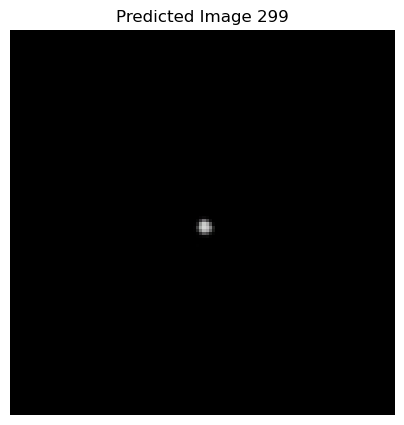

In [ ]:
i = np.random.randint(len(mask_test)/2)
# Display the selected ground truth and predicted mask
plt.figure(figsize=(5, 5))
plt.imshow(predictions[i], cmap='gray')  # Change to `mask_train[i]` to see the ground truth
plt.title(f"Predicted Image {i}")
plt.axis("off")
plt.show()